# **Examining Occupational Stereotypes (Ngrams)**
## **Goal**: Test relationships between occupational demographics and professions' feminization–masculiniztion.

### **Setup**
#### Imports

In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ngramprep.common.w2v_model import W2VModel
from analyze.cosine_similarity_time_series import cosine_similarity_over_years, plot_nearest_neighbors
from analyze.weat_time_series import compute_weat_over_years
from analyze.dimension_projection_time_series import compute_projection_over_years, compute_baseline_set
from analyze.pca_dimension_time_series import compute_pca_dimension_over_years
from analyze.semantic_drift import track_local_semantic_change, track_global_semantic_change, track_directional_drift
from analyze.average_relatedness_by_year import track_word_relatedness
from analyze.bls_utils import calculate_women_percentage, scrape_bls_professions_csv_batch

#### Specify model directory

In [2]:
model_path =  '/scratch/edk202/NLP_models/Google_Books/20200217/eng/5gram_files/models_final/norm_and_align'

### **Generate gender projection**
#### Use the `compute_meandiff_dimension` method to create a masculinization dimension

In [3]:
year = 2019
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('she', 'he'),
    ('her', 'his'),
    ('herself', 'himself'),
    ('woman', 'man'),
    ('women', 'men'),
    ('girl', 'boy'),
    ('girls', 'boys'),
    ('mother', 'father'),
    ('mothers', 'fathers'),
    ('daughter', 'son'),
    ('daughters', 'sons'),
    ('sister', 'brother'),
    ('sisters', 'brothers')
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

#### Print various words' projections on the masculinization dimension using the `print_word_projections` method

In [4]:
test_words = [
    # Clear anchors
    'husband', 'wife',
    'king', 'queen',

    # Historically masculine-stereotyped professions
    'engineer', 'physicist', 'soldier', 'pilot',
    'firefighter', 'mechanic', 'carpenter',
    'programmer', 'CEO', 'president',
    'construction_worker', 'plumber',

    # Historically feminine-stereotyped professions
    'nurse', 'teacher', 'secretary', 'receptionist',
    'librarian', 'babysitter', 'housekeeper',
    'caregiver', 'assistant', 'hairdresser',

    # Leadership / status roles (interesting test cases)
    'leader', 'manager', 'chairperson',
    'lawyer', 'doctor', 'scientist',
    'professor', 'judge',

    # Trait terms (useful for validating axis content)
    'strong', 'assertive', 'dominant',
    'competitive', 'logical', 'independent',
    'gentle', 'nurturing', 'empathetic',
    'emotional', 'supportive', 'caring'
]

projections = W2VModel.print_word_projections(model, meandiff_result['dimension'], test_words)


────────────────────────────────────────────────────────────────────────────────────────────────────
WORD PROJECTIONS ON DIMENSION
────────────────────────────────────────────────────────────────────────────────────────────────────
Word                           Projection                                           Visualization
────────────────────────────────────────────────────────────────────────────────────────────────────
  king                             0.2173                                              ██████
  leader                           0.1968                                               █████
  soldier                          0.1814                                               █████
  judge                            0.1453                                                ████
  physicist                        0.1350                                                ████
  president                        0.1335                                                ████
  en

### **Examine time-series**
#### Auto-generate a baseline trend using `compute_baseline_set` function

Using shared vocabulary: 27566 words found across all models

Baseline word set selection:
  Total vocabulary:          27,566
  Neutral candidates:        26,586 (after anchor & pattern exclusion)
  Selected neutral words:    22,834 (passed stability thresholds)

  Selection thresholds:
    |mu| < 0.080  (mean projection)
    |beta| < 0.0100  (trend/year)
    sigma < 0.150  (temporal variability)
    n >= 5  (minimum years)

  Neutral word statistics:
    Mean |mu|:     0.0323
    Mean |beta|:   0.0004
    Mean sigma:    0.0372

  Over-time correlation:
    Mean:          0.5051
    Median:        0.5038
    Std:           0.1124
    Range:         [0.2458, 0.7964]

  Aggregation:               mean



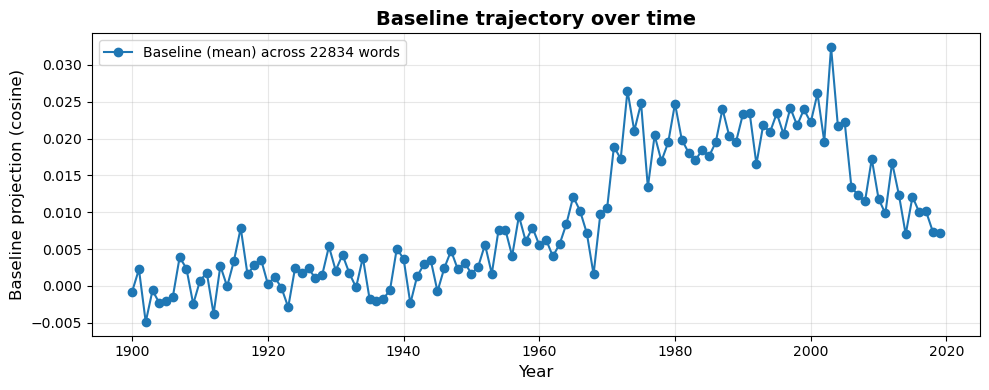

In [5]:
baseline_source = compute_baseline_set(
    model_dir=model_path,
    contrast_pairs=gender_contrasts,
    start_year=1900,
    end_year=2019,
    year_step=1,
    method='meandiff',
    exclusion_pattern=r"(man|men|woman|women|girl|boy|girls|boys|mother|father|mothers|fathers|daughter|son|daughters|sons|sister|brother)",
    eps_mean=0.08,
    eps_trend=0.010,
    eps_sigma=0.15,
    min_years=5,
    agg="mean",
    corr_n_permutations=0,
    verbose=True,
    plot_baseline=True
)

baseline_source = baseline_source["baseline"]

#### Altneratively, specify a set of baseline words

In [6]:
baseline_source = [
    'table', 'chair', 'window', 'door', 'wall', 'floor', 'roof', 'tree', 'leaf', 'branch', 'root', 'flower',
    'grass', 'water', 'stone', 'rock', 'sand', 'soil', 'clay', 'book', 'page', 'paper', 'pen', 'ink', 'cup',
    'plate', 'bowl', 'spoon', 'knife', 'fork', 'bread', 'cheese', 'butter', 'salt', 'sugar', 'road', 'path',
    'bridge', 'gate', 'fence', 'box', 'bag', 'basket', 'bottle', 'jar', 'horse', 'cow', 'sheep', 'pig',
    'chicken', 'dog', 'cat', 'sun', 'moon', 'star', 'cloud', 'rain', 'wind', 'river', 'lake', 'mountain',
    'hill', 'valley', 'wood', 'metal', 'iron', 'gold', 'silver', 'wheel', 'rope', 'chain', 'nail', 'hammer'
]

#### Specify the set of occupations from Caliskan et al. (2017)

In [7]:
targets = [
    "technician", "accountant", "supervisor", "engineer", "worker", "educator", "clerk", "counselor",
    "inspector", "mechanic", "manager", "therapist", "administrator", "salesperson", "receptionist", "librarian",
    "advisor", "pharmacist", "janitor", "psychologist", "physician", "carpenter", "nurse", "investigator",
    "bartender", "specialist", "electrician", "officer", "pathologist", "teacher", "lawyer", "planner",
    "practitioner", "plumber", "instructor", "surgeon", "veterinarian", "paramedic", "examiner", "chemist",
    "machinist", "appraiser", "nutritionist", "architect", "hairdresser", "baker", "programmer", "paralegal",
    "hygienist", "scientist"
]

#### Compute and plot masculinization time-series

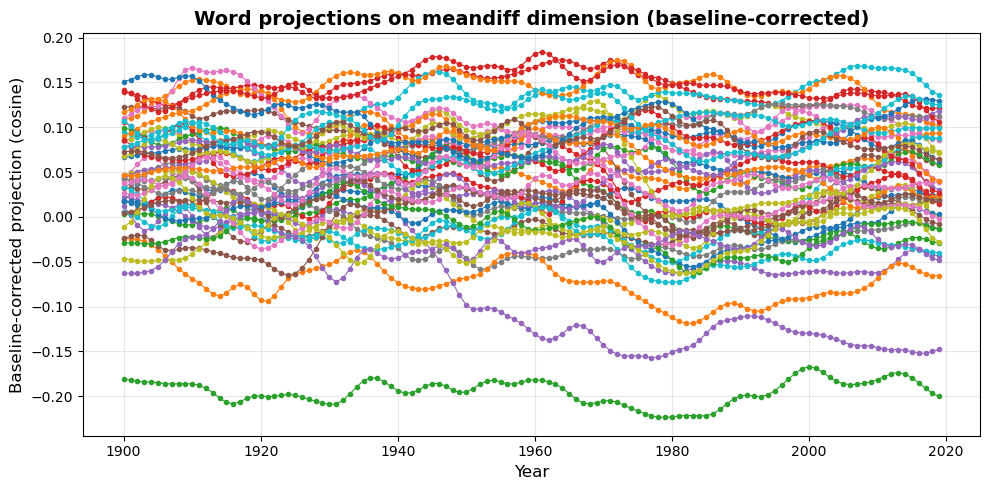

In [8]:
result = compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1900,
    end_year=2019,
    year_step=1,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=True,
    sigma=2,
    verbose=False,
    baseline_source=baseline_source,
    plot_corrected_if_baseline=True,
    plot=True,
 )

In [ ]:
# Correlation analysis with NaN handling and baseline correction option
from scipy.stats import pearsonr
import numpy as np

year_of_interest = 2015
bls_csv_path = '/scratch/edk202/lexichron/notebooks/professionsBLS_2015.csv'
use_baseline_corrected = True  # Set to True to use baseline-corrected projections if available

# Recompute BLS percentages for all targets
bls_percentages = {}
for profession in targets:
    try:
        pct = calculate_women_percentage(bls_csv_path, profession)
        bls_percentages[profession] = pct
    except (ZeroDivisionError, ValueError):
        pass

# Determine which projection data to use
if use_baseline_corrected and result.get('baseline_applied') and not result['projections_corrected'].empty:
    proj_year = result['projections_corrected'].loc[year_of_interest]
    projection_type = "Baseline-corrected"
    print(f"Using baseline-corrected projections")
else:
    proj_year = result['projections'].loc[year_of_interest]
    projection_type = "Raw"
    print(f"Using raw projections")

# Create common_profs: professions with both BLS data and projections for this year
common_profs = [p for p in targets if p in bls_percentages and p in proj_year.index]

# Filter to professions with valid (non-NaN) projection values
valid_profs = [p for p in common_profs if not pd.isna(proj_year[p])]

print(f"Valid professions (non-NaN projections): {len(valid_profs)} out of {len(common_profs)}")
print(f"Filtered out {len(common_profs) - len(valid_profs)} professions with NaN projections")

# Extract values for valid professions
bls_vals = np.array([bls_percentages[p] for p in valid_profs])
proj_vals = np.array([proj_year[p] for p in valid_profs])

# Compute correlation
if len(valid_profs) >= 3:
    corr, p_value = pearsonr(bls_vals, proj_vals)
    
    print(f"\n=== Correlation Results ({projection_type}) ===")
    print(f"Pearson r = {corr:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"n = {len(valid_profs)} professions")
    
    # Create scatter plot
    plt.figure(figsize=(10, 7))
    plt.scatter(bls_vals, proj_vals, alpha=0.6, s=120, edgecolors='black', linewidth=0.5)
    
    # Add profession labels
    for i, prof in enumerate(valid_profs):
        plt.annotate(prof, (bls_vals[i], proj_vals[i]), 
                    fontsize=9, alpha=0.8, ha='center')
    
    # Add regression line
    z = np.polyfit(bls_vals, proj_vals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(bls_vals.min(), bls_vals.max(), 100)
    plt.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Linear fit')
    
    plt.xlabel("BLS Women Percentage (2015)", fontsize=12, fontweight='bold')
    plt.ylabel(f"Gender Projection Score ({year_of_interest}) - {projection_type}", fontsize=12, fontweight='bold')
    plt.title(f"Word Embeddings vs. Real-World Gender Demographics\nPearson r = {corr:.4f}, p = {p_value:.6f}", 
              fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    if p_value < 0.05:
        print(f"\n✓ Significant correlation (p < 0.05)")
    else:
        print(f"\n✗ Not statistically significant (p >= 0.05)")
else:
    print(f"ERROR: Not enough valid professions ({len(valid_profs)} found)")

#### Make file list for BLS data download

In [5]:
file_list = [
    "https://www.bls.gov/cps/cpsaat11.htm",
    "https://www.bls.gov/cps/data/aa2024/cpsaat11.htm",
    "https://www.bls.gov/cps/data/aa2023/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2022/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2021/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2020/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2019/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2018/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2017/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2016/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2015/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2014/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2013/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2012/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2011/cpsaat11.htm",
    "https://www.bls.gov/cps/aa2010/aat11.txt",
    "https://www.bls.gov/cps/aa2009/aat11.txt",
    "https://www.bls.gov/cps/aa2008/aat11.txt",
    "https://www.bls.gov/cps/aa2007/aat11.txt",
    "https://www.bls.gov/cps/aa2006/aat11.txt",
    "https://www.bls.gov/cps/aa2005/aat11.txt",
    "https://www.bls.gov/cps/aa2004/aat11.txt",
    "https://www.bls.gov/cps/aa2003/aat11.txt",
    "https://www.bls.gov/cps/aa2002/aat11.txt",
    "https://www.bls.gov/cps/aa1999/AAT11.TXT",
    "https://www.bls.gov/cps/aa1998/AAT11.TXT",
    "https://www.bls.gov/cps/aa1997/AAT11.TXT",
    "https://www.bls.gov/cps/aa1996/AAT11.TXT",
    "https://www.bls.gov/cps/aa1995/AAT11.TXT"
]

In [6]:
output_dir = '/scratch/edk202/lexichron/notebooks/bls_scraped'

runs_df = scrape_bls_professions_csv_batch(
    file_list=file_list,
    output_dir=output_dir,
    output_basename='professionsBLS.csv',
    inject_year_in_filename=True,
    continue_on_error=True,
    request_timeout=20,
    request_retries=1,
)

print(f"Completed: {(runs_df['status'] == 'ok').sum()} succeeded, {(runs_df['status'] == 'failed').sum()} failed")
runs_df

Detected BLS reference year from page content: 2025
Saved 396 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2025.csv
Detected BLS reference year from page content: 2024
Saved 383 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2024.csv
Detected BLS reference year from page content: 2023
Saved 386 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2023.csv
Detected BLS reference year from page content: 2022
Saved 392 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2022.csv
Detected BLS reference year from page content: 2021
Saved 384 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2021.csv
Detected BLS reference year from page content: 2020
Saved 387 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2020.csv
Detected BLS reference year from page content: 2019
Saved 361 rows to /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_2019.csv
Detect

,year,rows,status,output_csv,url,error
0,2025,396,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/cpsaat11.htm,
1,2024,383,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/data/aa2024/cpsaat11.htm,
2,2023,386,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/data/aa2023/cpsaat11.htm,
3,2022,392,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2022/cpsaat11.htm,
4,2021,384,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2021/cpsaat11.htm,
5,2020,387,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2020/cpsaat11.htm,
6,2019,361,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2019/cpsaat11.htm,
7,2018,361,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2018/cpsaat11.htm,
8,2017,361,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2017/cpsaat11.htm,
9,2016,359,ok,/scratch/edk202/lexichron/notebooks/bls_scrape...,https://www.bls.gov/cps/aa2016/cpsaat11.htm,


In [11]:
# Regression guard: exact label-column matching in calculate_women_percentage
from pathlib import Path
import math

notebooks_root = Path("/scratch/edk202/lexichron/notebooks")
found_csvs = sorted(notebooks_root.rglob("professionsBLS*.csv"))
assert found_csvs, "No professionsBLS*.csv files found under /scratch/edk202/lexichron/notebooks"

csv_path = str(found_csvs[0])
print("Using CSV:", csv_path)

# Positive controls: should resolve to finite percentages
positive_terms = ["engineer", "nurse", "manager"]
for term in positive_terms:
    pct = calculate_women_percentage(csv_path, term)
    assert math.isfinite(pct), f"Expected finite pct for '{term}', got {pct}"
    assert 0.0 <= pct <= 1.0, f"Expected pct in [0,1] for '{term}', got {pct}"

# Negative controls: should NOT match exact label columns
negative_terms = ["and", "man"]
for term in negative_terms:
    try:
        _ = calculate_women_percentage(csv_path, term)
        raise AssertionError(f"Expected no exact label match for '{term}', but got a value")
    except ZeroDivisionError:
        pass

print("✅ Exact label matching regression check passed")

Using CSV: /scratch/edk202/lexichron/notebooks/bls_scraped/professionsBLS_1995.csv
✅ Exact label matching regression check passed
